<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Clustering based Course Recommender System**


## **Introduction**
In lab 6.2.1, we created user profile vectors based on the courses each user has taken and the genres of those courses.

A user profile vector may look like a row vector in the following matrix, for example, we can see the Database column for user2 has a value 1 which means user2 is very interesting in courses related to the databases. With these **user profile vectors**, we can compare users and find users with similar interests. 

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_3/images/userprofiles.png)


Instead of comparing users one by one, we can use clustering algorithms such as K-means or DBSCAN to automatically group users into several clusters. Each cluster represents a group of users who have similar learning preferences. For example, in the below user clusters, we have user clusters whom have learned courses related to machine learning, cloud computing, databases, and web development, etc.


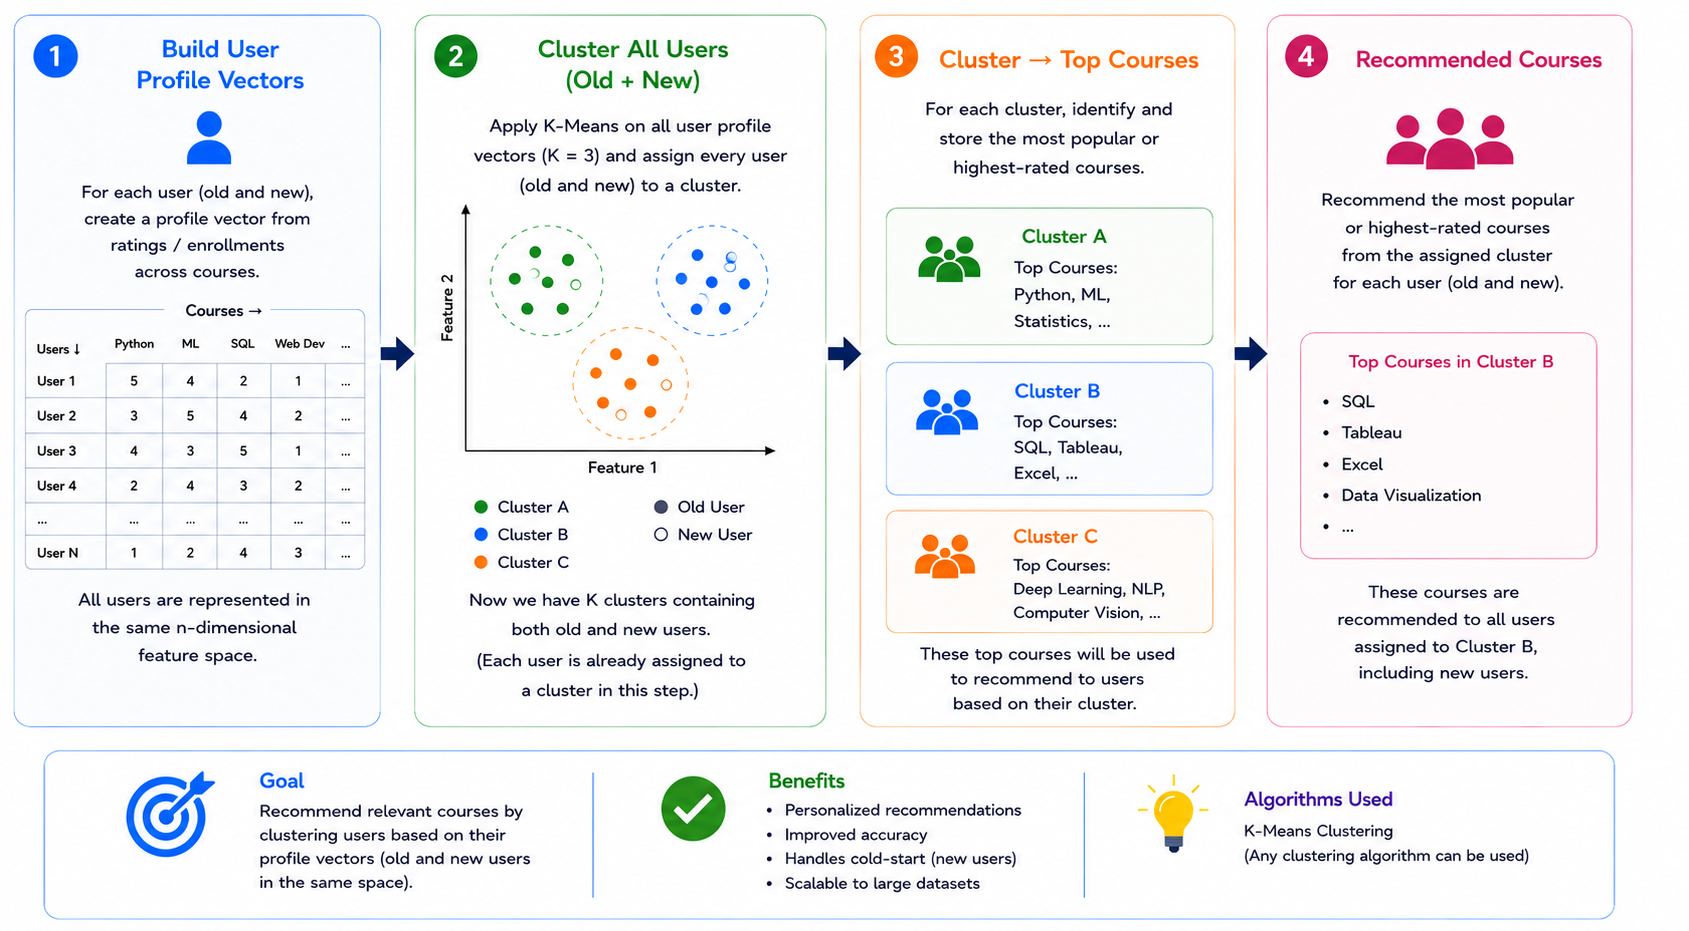

The user profile vectors may contain many dimensions, which can make clustering difficult.
To study how dimensionality affects clustering, in this lab we will perform clustering both before and after dimensionality reduction.

For dimensionality reduction, we use Principal Component Analysis (PCA) to reduce the number of genre features while keeping the most important information in the data. After PCA, we apply K-means clustering again on the reduced vectors and compare the results.

After users are grouped, we can analyze the courses taken by users in the same cluster.
For each cluster, we can count which courses are most popular among users in that group.
For example, for the machine learning user cluster/learning group, we can count the most frequently enrolled courses, which are very likely to be the most popular and good machine learning courses because they are enrolled by many users who are interested in machine learning. 

These popular courses can then be recommended to other users who belong to the same cluster. 


In this lab, you will duild a clustering-based recommender system.


## **Objectives**


* Perform k-means clustering on the original user profile feature vectors
* Apply PCA (Principle Component Analysis ) on user profile feature vectors to reduce dimensions
* Perform k-means clustering on the PCA transformed main components
* Generate course recommendations based on other group members' enrollment history


----


## **Prepare and setup lab environment**


First install and import required libraries:


In [ ]:
# %pip install scikit-learn
# %pip install seaborn
# %pip install pandas
# %pip install matplotlib

In [350]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [351]:
# also set a random state
rs = 123

### **Load the user profile dataset**


Let's first load the original user profile feature vectors:


In [ ]:
# Defining the URL of the CSV file containing user profiles
user_profile_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv"

# Using pandas' read_csv function to read the CSV file from the specified URL into a DataFrame
user_profile_df = pd.read_csv(user_profile_url)

# Displaying the first few rows of the DataFrame to inspect its contents
user_profile_df.head()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


In [353]:
user_profile_df.shape

(33901, 15)

we can then list the feature names, they are the user interested topics (course genres):


In [354]:
feature_names = list(user_profile_df.columns[1:])
feature_names

['Database',
 'Python',
 'CloudComputing',
 'DataAnalysis',
 'Containers',
 'MachineLearning',
 'ComputerVision',
 'DataScience',
 'BigData',
 'Chatbot',
 'R',
 'BackendDev',
 'FrontendDev',
 'Blockchain']

As we can see from the user profile dataset, we have about 33K unique users with interests in areas like ``Database``, ``Python``, ``CloudComputing``, etc. Then, let's check the  summary statistics for each feature.


In [355]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000
mean,1.064064e+06,5.518569,3.493791,2.307100,3.624701,0.998938,3.048022,0.001770,5.087343,4.750450,0.462995,1.017433,2.269461,0.315802,0.986844
std,4.972578e+05,7.611941,4.227254,3.841858,4.760135,2.351764,4.624004,0.072846,5.230697,7.216228,1.055186,2.342532,4.310752,1.363462,1.950585
min,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.813480e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.043907e+06,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.451159e+06,9.000000,6.000000,3.000000,6.000000,0.000000,3.000000,0.000000,9.000000,6.000000,0.000000,0.000000,3.000000,0.000000,2.000000
max,2.103039e+06,63.000000,18.000000,38.000000,48.000000,15.000000,39.000000,3.000000,32.000000,54.000000,6.000000,18.000000,54.000000,15.000000,12.000000


#### **Data preprocessing with normalization**

The original user profile feature vector is not normalized, which may cause issues when we perform clustering and Principal component analysis (PCA), therefor we standardize the data.


In [ ]:
# Use StandardScaler to make each feature with mean 0, standard deviation 1
# Instantiating a StandardScaler object
scaler = StandardScaler()

# Standardizing the selected features (feature_names) in the user_profile_df DataFrame
user_profile_df[feature_names] = scaler.fit_transform(
    user_profile_df[feature_names]
)

# Printing the mean and standard deviation of the standardized features
print(
    "mean {} and standard deviation{} ".format(
        user_profile_df[feature_names].mean(),
        user_profile_df[feature_names].std(),
    )
)

mean Database          -3.353495e-17
Python            -5.700942e-17
CloudComputing    -3.521170e-17
DataAnalysis      -7.671120e-17
Containers         3.353495e-18
MachineLearning    3.688845e-17
ComputerVision    -1.509073e-17
DataScience       -1.676748e-17
BigData            6.706990e-17
Chatbot           -6.874665e-17
R                  4.233788e-17
BackendDev         1.383317e-17
FrontendDev        5.051202e-17
Blockchain        -5.281755e-17
dtype: float64 and standard deviationDatabase           1.000015
Python             1.000015
CloudComputing     1.000015
DataAnalysis       1.000015
Containers         1.000015
MachineLearning    1.000015
ComputerVision     1.000015
DataScience        1.000015
BigData            1.000015
Chatbot            1.000015
R                  1.000015
BackendDev         1.000015
FrontendDev        1.000015
Blockchain         1.000015
dtype: float64 


In [357]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04
mean,1.064064e+06,-3.353495e-17,-5.700942e-17,-3.521170e-17,-7.671120e-17,3.353495e-18,3.688845e-17,-1.509073e-17,-1.676748e-17,6.706990e-17,-6.874665e-17,4.233788e-17,1.383317e-17,5.051202e-17,-5.281755e-17
std,4.972578e+05,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,2.000000e+00,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
25%,6.813480e+05,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
50%,1.043907e+06,-3.308757e-01,-1.168130e-01,-6.005256e-01,-1.312380e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-3.990622e-01,-3.811535e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
75%,1.451159e+06,4.573712e-01,5.928781e-01,1.803581e-01,4.990056e-01,-4.247674e-01,-1.038556e-02,-2.429612e-02,7.480294e-01,1.731609e-01,-4.387873e-01,-4.343370e-01,1.694715e-01,-2.316212e-01,5.194189e-01
max,2.103039e+06,7.551593e+00,3.431642e+00,9.290667e+00,9.322416e+00,5.953517e+00,7.775190e+00,4.115884e+01,5.145214e+00,6.824934e+00,5.247500e+00,7.249771e+00,1.200053e+01,1.076995e+01,5.646161e+00


The normalized user profile features are: 


In [ ]:
features = user_profile_df.loc[:, user_profile_df.columns != "user"]
features

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419
2,2.427988,1.066006,4.084776,4.280467,-0.424767,5.828796,-0.024296,3.233395,1.281790,1.456642,5.542191,5.505047,2.702132,2.570116
3,-0.462250,-0.826504,-0.600526,-0.341319,-0.424767,-0.659184,-0.024296,-0.972608,-0.381153,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
4,0.063248,-0.826504,-0.600526,0.078843,-0.424767,-0.659184,-0.024296,-0.972608,0.173161,-0.438787,0.419453,-0.526473,-0.231621,-0.505930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33896,-0.330876,-0.116813,0.180358,0.499006,-0.424767,-0.659184,-0.024296,0.174484,-0.658311,-0.438787,2.127032,0.865416,-0.231621,1.032093
33897,-0.724999,-0.826504,-0.079936,-0.761482,-0.424767,-0.659184,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
33898,-0.330876,0.592878,0.961242,-0.761482,-0.424767,2.368540,-0.024296,0.748029,-0.658311,-0.438787,0.846348,-0.526473,-0.231621,-0.505930
33899,-0.724999,-0.826504,-0.600526,-0.761482,-0.424767,-0.226652,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930


we can also save the user ids for later recommendation tasks:


In [ ]:
user_ids = user_profile_df.loc[:, user_profile_df.columns == "user"]
user_ids

,user
0,2
1,4
2,5
3,7
4,8
...,...
33896,2102054
33897,2102356
33898,2102680
33899,2102983


### **Perform K-means clustering algorithm on the user profile feature vectors**


With the user profile dataset ready, you need to use the `KMeans` class provided by scikit-learn library to perform clustering on the user profile feature vectors. 


For `KMeans` algorithm, one important hyperparameter is the number of clusters `n_cluster`, and a good way to find the optimized `n_cluster` is using to grid search a list of candidates and find the one with the best or optimized clustering evaluation metrics such as minimal **inertia** or more precisely **silhouette score**:


_TODO: grid search the optimized n_cluster for KMeans() model_


In [ ]:
# Initialize an empty list to store the sum of squared distances for each model
results = []

for k in range(2, 30):  # silhouette needs k >= 2
    km = KMeans(n_clusters=k, random_state=rs)
    labels = km.fit_predict(features)

    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(features, labels),
        }
    )


metrics_df = pd.DataFrame(results)

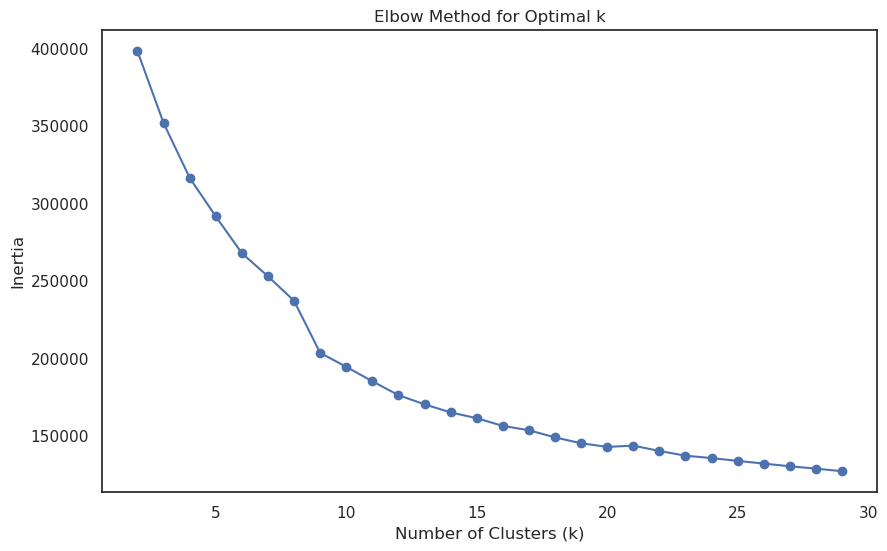

In [ ]:
# Plot the sum of squared distances against the number of clusters
plt.figure(figsize=(10, 6))

plt.plot(metrics_df["k"], metrics_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()
# Find an optimized number of neighors k from a candidate list such as list_k = list(range(1, 30))

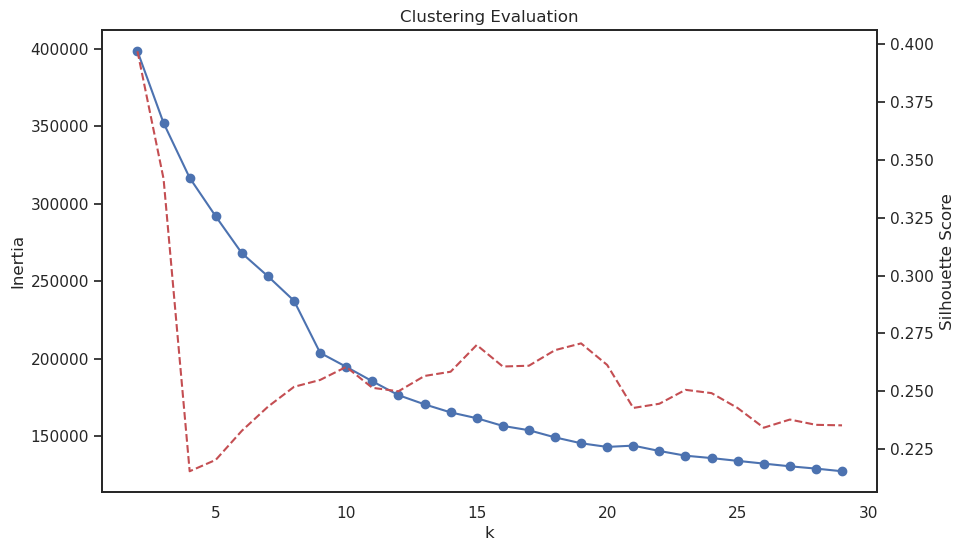

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Inertia
ax1.plot(metrics_df["k"], metrics_df["inertia"], "o-", label="Inertia")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

# Silhouette
ax2 = ax1.twinx()
ax2.plot(metrics_df["k"], metrics_df["silhouette"], "r--", label="Silhouette")
ax2.set_ylabel("Silhouette Score")

plt.title("Clustering Evaluation")
plt.show()

<details>
    <summary>Click here for Hints</summary>
    
Create a list that will hold the the sum of square distances for each fitted model. For each k in `n_clusters` make a model by calling `KMeans(n_clusters=k, random_state=rs).fit(features)` ans append `model.inertia_` to the list. Plot square distances against the k values.  

</details>


**The two metrics do NOT agree perfectly**
1. Inertia (blue line) → efficiency / compactness

    Inertia drops very fast from k = 2 → ~8–10 \
    Clear elbow around k ≈ 10 \
    After k ≈ 10, the curve flattens
    Adding more clusters beyond ~10 gives diminishing returns

    **Elbow ≈ 8–12**

2. Silhouette score (red dashed line) → separation / quality

    Highest at k = 2 (~0.40), and drops sharply at k=3–4 (common behavior) \
    Then gradually increases and stabilizes \
    Peak around k ≈ 15–20 (~0.26–0.27) \
    Silhouette values are low (~0.25), indicating overlapping clusters and overlapping feature space.
    This means: Best separation (excluding trivial k=2) is around k ≈ 15–20

3. Practical choice: k ≈ 10–15    

Once we have identified the best number of clusters, you can apply `KMeans()` again to generate cluster label for all users.


In [363]:
cluster_labels = [None] * len(user_ids)

_TODO: Apply KMeans() on the features with optimized n_cluster parameter after model fitting, you can find output cluster labels in `model.labels_` attribute_


In [ ]:
# Set the optimized number of clusters based on the elbow plot
optimal_n_clusters = 12

# Apply KMeans with the optimized number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=rs)
kmeans.fit(features)

# Get the cluster labels
cluster_labels = kmeans.labels_
cluster_labels

array([ 7, 11,  7, ...,  1,  6,  6], dtype=int32)

<details>
    <summary>Click here for Hints</summary>
    
Create  a model by calling `KMeans(n_clusters=k, random_state=rs).fit(features)`. Save the labels by accessing `model.labels`.

</details>


The cluster labels you generated is a list of integers indicating cluster indices. You may use the following utility method to combine the cluster labels and user ids to a dataframe, so that you know which cluster a user belongs:


In [ ]:
def combine_cluster_labels(user_ids, labels):
    # Convert labels to a DataFrame
    labels_df = pd.DataFrame(labels)
    # Merge user_ids DataFrame with labels DataFrame based on index
    cluster_df = pd.merge(
        user_ids, labels_df, left_index=True, right_index=True
    )
    # Rename columns to 'user' and 'cluster'
    cluster_df.columns = ["user", "cluster"]
    return cluster_df

In [ ]:
cluster_df = combine_cluster_labels(user_ids, cluster_labels)
cluster_df

,user,cluster
0,2,7
1,4,11
2,5,7
3,7,6
4,8,6
...,...,...
33896,2102054,5
33897,2102356,6
33898,2102680,1
33899,2102983,6


Now, each user finds its own cluster or we can say we have created many clusters of learning communities. Learners within each community share very similar learning interests.


### **Apply PCA on user profile feature vectors to reduce dimensions**


In the previous step, we applied `KMeans` on the original user profile feature vectors which have 14 original features (the course genres).


In [ ]:
# Extracting features from the user_profile_df DataFrame, excluding the 'user' column
features = user_profile_df.loc[:, user_profile_df.columns != "user"]

# Extracting user IDs from the user_profile_df DataFrame
user_ids = user_profile_df.loc[:, user_profile_df.columns == "user"]

# Creating a list of feature names by excluding the 'user' column name
feature_names = list(user_profile_df.columns[1:])

In [368]:
print(f"There are {len(feature_names)} features for each user profile.")

There are 14 features for each user profile.


If we plot a covariance matrix of the user profile feature vectors with 14 features, we can observe that some features are actually correlated:


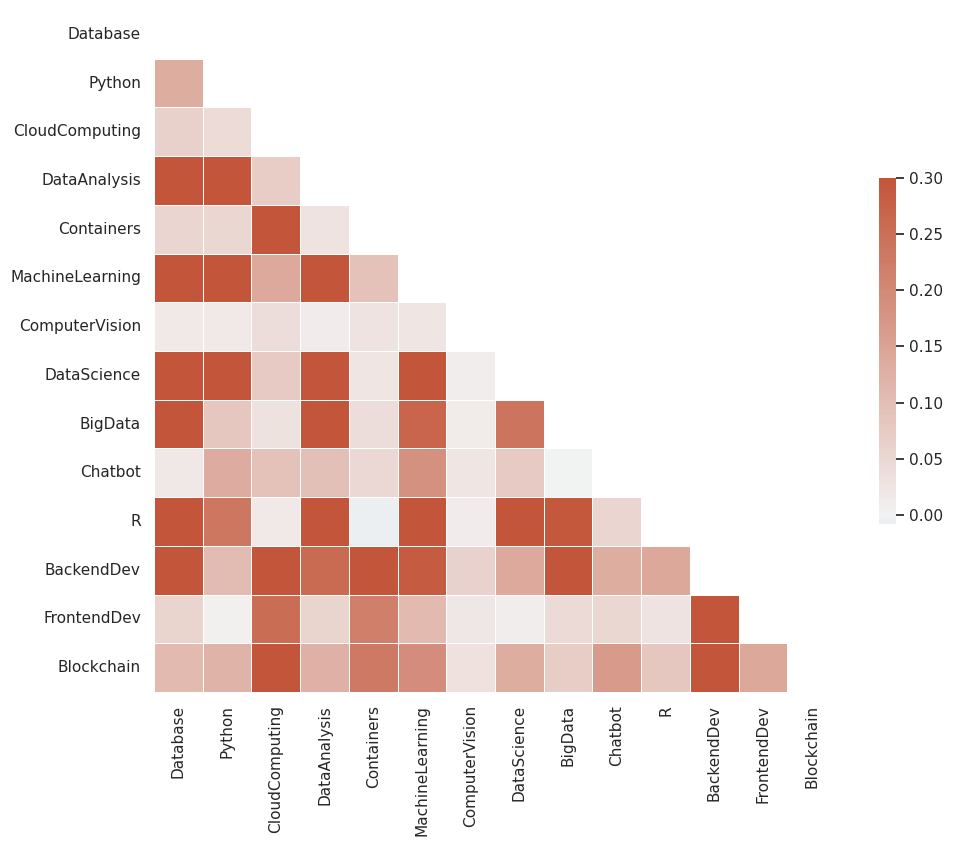

In [ ]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = features.cov()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=0.3,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)


plt.show()

For example, the feature `MachineLearning` and the feature `DataScience` are correlated. Such covariances among features may indicate that we can apply PCA to find its main components (eigenvectors with max eigenvalues on the covariance matrix). 

If we only keep the independent main components, then we can reduce the dimensions of our user profile feature vectors.


Now let's apply the `PCA()` provided by  `scikit-learn` to find the main components in user profile feature vectors and see if we can reduce its dimensions by only keeping the main components.


Note that when calling the  `PCA()` class, there is also an import argument called `n_components` which indicates how many components you want to keep in the PCA result. One way to find an optimized `n_components` is to do a grid search on a list of argument candidates (such as `range(1, 15)`) and calculate the ratio of the accumulated variance for each candidate. 

If the accumulated variances ratio of a candidate `n_components` is larger than a threshold, e.g., 90%, then we can say the transformed `n_components` could explain about 90% of variances of the original data variance and can be considered as an optimized components size.


_TODO: Find the optimized `n_components` for PCA_


In [ ]:
# - For a list of candidate `n_components` arguments such as 1 to 14, find out the minimal `n` that can explain accumulated 90% variances of previous data
# - In the fitted PCA() model, you can find explained_variance_ratio_ and use the sum() function to add them to get the accumulated variance ratio
from sklearn.decomposition import PCA

pca_list = list()
feature_weight_list = list()

# Fit a range of PCA models
for n in range(1, 15):

    # Create and fit the model
    PCAmod = PCA(n_components=n)
    PCAmod.fit(features)

    # Store the model and variance
    pca_list.append(
        pd.Series(
            {
                "n": n,
                "model": PCAmod,
                "var": PCAmod.explained_variance_ratio_.sum(),
            }
        )
    )

    # Calculate and store feature importances
    abs_feature_values = np.abs(PCAmod.components_).sum(axis=0)
    feature_weight_list.append(
        pd.DataFrame(
            {
                "n": n,
                "features": features.columns,
                "values": abs_feature_values / abs_feature_values.sum(),
            }
        )
    )

pca_df = pd.concat(pca_list, axis=1).T.set_index("n")
pca_df

,model,var
n,,
1,PCA(n_components=1),0.287568
2,PCA(n_components=2),0.463093
3,PCA(n_components=3),0.576134
4,PCA(n_components=4),0.648747
5,PCA(n_components=5),0.719488
6,PCA(n_components=6),0.78821
7,PCA(n_components=7),0.842956
8,PCA(n_components=8),0.894445
9,PCA(n_components=9),0.92727


In [ ]:
features_df = pd.concat(feature_weight_list).pivot(
    index="n", columns="features", values="values"
)

features_df

features,BackendDev,BigData,Blockchain,Chatbot,CloudComputing,ComputerVision,Containers,DataAnalysis,DataScience,Database,FrontendDev,MachineLearning,Python,R
n,,,,,,,,,,,,,,
1,0.088497,0.095053,0.054786,0.028111,0.052312,0.007183,0.043639,0.119681,0.096857,0.103455,0.041011,0.102603,0.081675,0.085137
2,0.108141,0.070314,0.071404,0.024387,0.098156,0.009681,0.089826,0.094353,0.079767,0.073851,0.072760,0.067664,0.066668,0.073029
3,0.089201,0.106619,0.062641,0.042209,0.077122,0.007962,0.067335,0.066497,0.086504,0.104829,0.059513,0.077392,0.094209,0.057967
4,0.082738,0.083776,0.057565,0.076008,0.084550,0.054436,0.083450,0.054937,0.077510,0.082011,0.072318,0.063492,0.078357,0.048852
5,0.082719,0.074558,0.050645,0.072922,0.087636,0.096843,0.088705,0.046503,0.066676,0.072968,0.094862,0.057041,0.065980,0.041942
6,0.077416,0.071397,0.061144,0.099607,0.079294,0.100142,0.076731,0.040363,0.063538,0.069478,0.107377,0.050401,0.060941,0.042171
7,0.070887,0.066148,0.093421,0.105869,0.074203,0.087781,0.083753,0.039210,0.059532,0.063123,0.099957,0.046932,0.061227,0.047955
8,0.065388,0.064403,0.092021,0.103771,0.070532,0.078415,0.079487,0.039855,0.057333,0.060085,0.089788,0.044667,0.075733,0.078522
9,0.060307,0.059826,0.085677,0.100489,0.065108,0.072178,0.073207,0.041566,0.072914,0.056571,0.087210,0.075053,0.076224,0.073668


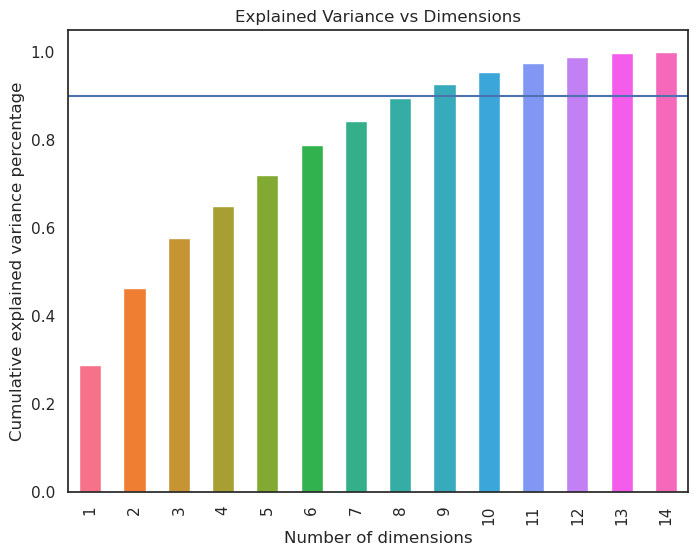

In [ ]:
plt.figure(figsize=(8, 6))
colors = sns.color_palette("husl", len(pca_df))

ax = pca_df["var"].plot(kind="bar", color=colors)

ax.set(
    xlabel="Number of dimensions",
    ylabel="Cumulative explained variance percentage",
    title="Explained Variance vs Dimensions",
)

plt.axhline(y=0.9, color="b", linestyle="-", label="90% Variance Explained")
plt.show()

<details>
    <summary>Click here for Hints</summary>
    
* For each `n_components` from 1 to 14 you can call `PCA=PCA(n_components=component)`, then you can simply fit it by callsing `pca.fit_transform(features)` where `features = user_profile_df.loc[:, user_profile_df.columns != 'user']`. 
* Then you can find `accumulated_variance_ratios` by applying `sum()` to `pca.explained_variance_ratio_`. 
* Then find the smallest n_components value for which `accumulated_variance_ratios >= 0.9` and return it.
</details>


Once you found the optimized `n_component` argument value, you can apply PCA on the user profile feature vectors and reduce the  14 features into  `n_component` features.


_TODO: Perform PCA to transform original user profile features_


In [373]:
# find out the minimal `n` that can explain accumulated 90% variances of previous data
pca = PCA(n_components=9)
transformed_features = pca.fit_transform(features)

print("Optimized n_components:", pca.n_components_)

Optimized n_components: 9


In [374]:
transformed_features

array([[17.77249439,  0.20068141,  1.73060927, ...,  0.681042  ,
         2.31261304,  0.86827151],
       [ 7.14519863, -2.84748121,  2.3586356 , ...,  0.54976933,
         0.46903346,  0.03340487],
       [11.36326985,  1.8736192 , -1.52207738, ...,  1.67758234,
         2.9376687 ,  2.09763858],
       ...,
       [ 0.62594328, -0.54716673, -1.69282423, ..., -0.05509971,
         0.58209105,  1.70319253],
       [-2.03683187, -0.15353383,  0.16285226, ...,  0.07249638,
         0.11374975,  0.62289958],
       [-2.03683187, -0.15353383,  0.16285226, ...,  0.07249638,
         0.11374975,  0.62289958]])

In [ ]:
# Create a DataFrame for the transformed features
transformed_features_df = pd.DataFrame(
    transformed_features,
    columns=[f"PC{i}" for i in range(transformed_features.shape[1])],
)

# Merge the user ids and transformed features into a new dataframe
pca_user_profile_df = pd.merge(
    user_ids, transformed_features_df, left_index=True, right_index=True
).set_index("user")
pca_user_profile_df

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
user,,,,,,,,,
2,17.772494,0.200681,1.730609,2.567359,-3.825814,-2.707154,0.681042,2.312613,0.868272
4,7.145199,-2.847481,2.358636,-0.576654,0.398803,0.134533,0.549769,0.469033,0.033405
5,11.363270,1.873619,-1.522077,1.076144,-1.711688,-0.883212,1.677582,2.937669,2.097639
7,-1.834033,-0.277462,0.564905,0.053470,-0.064440,-0.165757,0.030956,0.039519,0.210887
8,-1.049125,-0.684767,1.072765,0.006371,-0.005695,-0.118686,0.118559,0.559292,0.186379
...,...,...,...,...,...,...,...,...,...
2102054,0.633824,0.108815,-0.388871,-0.122665,-0.098364,-0.358333,1.752049,1.486542,-0.523600
2102356,-2.095339,0.135058,0.244727,-0.088185,0.025081,-0.183641,0.046413,0.191709,0.260437
2102680,0.625943,-0.547167,-1.692824,-0.630589,0.166632,-0.676244,-0.055100,0.582091,1.703193


<details>
    <summary>Click here for Hints</summary>
    
* Call PCA class as `pca = PCA(n_components=n_components)` 
* Fit PCA model using predefined `features` variable as only parameter
* Get the components by calling `pca.fit_transform(features)` 
* Create a `pd.DataFrame(data=components)` and use `pd.merge` to merge it with `user_ids` don't forget to specify `left_index=True, right_index=True` in `merge` function parameters.
    
</details> 
    


Your PCA transformed dataframe may look like the following:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_3/images/pca_res.png)


### **Perform k-means clustering on the PCA transformed feature vectors**


Now, you have the PCA  components of the original profile vectors. You can perform k-means on them again:


_TODO: Perform K-means on the PCA transformed features_


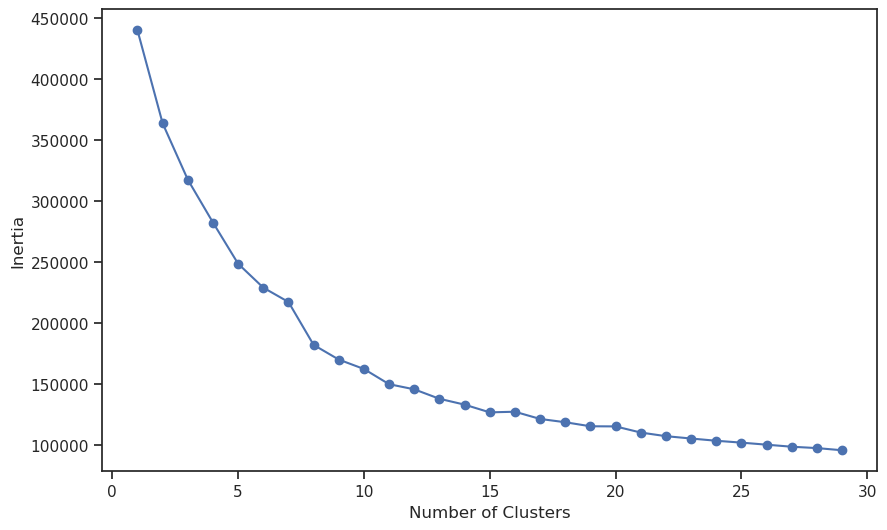

In [ ]:
# Initialize an empty list to store the sum of squared distances for each model
inertia = []

# Define a range of candidate values for the number of clusters
list_num_clusters = list(range(1, 30))

# Perform K-means clustering for each candidate value of k
for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters, random_state=rs)
    ## - Apply KMeans() on the PCA features
    km.fit(pca_user_profile_df)
    # Append the sum of squared distances to the list
    inertia.append(km.inertia_)

# Plot the sum of squared distances against the number of clusters
plt.figure(figsize=(10, 6))
plt.plot(list_num_clusters, inertia)
plt.scatter(list_num_clusters, inertia)
plt.tick_params(axis="both", which="both", bottom=True, left=True)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
# Find an optimized number of neighors k from a candidate list such as list_k = list(range(1, 30))

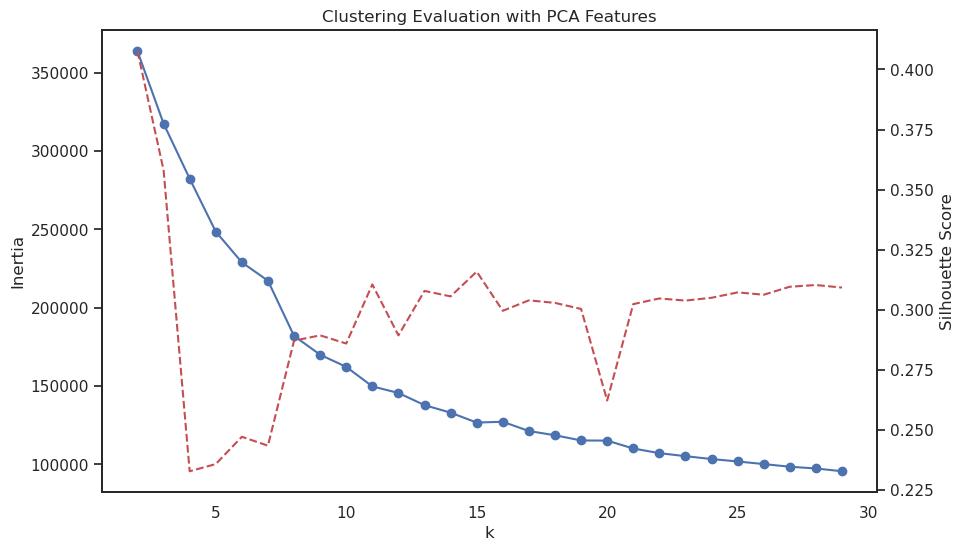

In [ ]:
# Initialize an empty list to store the sum of squared distances for each model
results = []

for k in range(2, 30):  # silhouette needs k >= 2
    km = KMeans(n_clusters=k, random_state=rs)
    labels = km.fit_predict(pca_user_profile_df)

    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(pca_user_profile_df, labels),
        }
    )


metrics_df = pd.DataFrame(results)

# Plot the sum of squared distances against the number of clusters
fig, ax1 = plt.subplots(figsize=(10, 6))

# Inertia
ax1.plot(metrics_df["k"], metrics_df["inertia"], "o-", label="Inertia")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

# Silhouette
ax2 = ax1.twinx()
ax2.plot(metrics_df["k"], metrics_df["silhouette"], "r--", label="Silhouette")
ax2.set_ylabel("Silhouette Score")

plt.title("Clustering Evaluation with PCA Features")
plt.show()

In [ ]:
# Set the optimized number of clusters based on the elbow plot
optimal_n_clusters = 12

# Apply KMeans with the optimized number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=rs)
kmeans.fit(pca_user_profile_df)

# Obtain the cluster label lists from model.labels_ attribute
cluster_labels = kmeans.labels_
cluster_labels

array([8, 8, 3, ..., 6, 2, 2], dtype=int32)

In [379]:
# Assign each user a cluster label by combining user ids and cluster labels
cluster_df = combine_cluster_labels(user_ids, cluster_labels)
cluster_df

,user,cluster
0,2,8
1,4,8
2,5,3
3,7,2
4,8,9
...,...,...
33896,2102054,1
33897,2102356,2
33898,2102680,6
33899,2102983,2


Great, now all users find their learning interest groups, either based on their original or the PCA transformed user profile features. 


When a user is in a group or a community, it is very likely that the user will be interested in the courses enrolled by other members within the same group.


### **Generate course recommendations based on the popular courses in the same cluster**


The Intuition of clustering-based course recommendation is very simple and can be illustrated via the following example:


Suppose a user has joined a machine learning group (via clustering algorithm). In the group, he/she finds that the top-3 courses enrolled by all other group members are `Machine Learning for Everyone`, `Machine Learning with Python`, `Machine Learning with Scikit-learn`. Since the user has already completed the `Machine Learning for Everyone` earlier, he/she decides to trust the group members' choices and enroll in other two unselected courses `Machine Learning with Python` and `Machine Learning with Scikit-learn`.


In summary, the clustering-based recommender system first groups all users based on their profiles, and maintains a popular courses list for each group. For any group member who needs course recommendations, the algorithm recommends the unselected courses from the popular course lists.
- find the user’s cluster
- find the courses that are popular in that cluster
- remove the courses the user already took
- recommend the remaining courses

Next, suppose we have a set of test users, and we want to recommend new courses to them using a clustering-based recommender system:


#### **Step 1: attach the cluster label in the user item interaction matrix**

In [ ]:
# test_user_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
test_user_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/rs_content_test.csv"

# Reading the test user data CSV file into a pandas DataFrame
# Selecting only the 'user' and 'item' columns using indexing
test_users_df = pd.read_csv(test_user_url)[["user", "item"]]

# Displaying the first few rows of the DataFrame to inspect its contents
test_users_df

,user,item
0,1502801,RP0105EN
1,1609720,CNSC02EN
2,1347188,CO0301EN
3,755067,ML0103EN
4,538595,BD0115EN
...,...,...
9397,1385217,EE0101EN
9398,1864644,DA0101EN
9399,435858,TMP0105EN
9400,1888188,DB0101EN


The test users dataset has only two columns, the user id and the enrolled course id. 


For each user, let's find its cluster label using the k-means results you have performed in previous steps, assuming it is named `cluster_df`.


You can assign the cluster label to all test users via merging the clustering labels (`cluster_df`:):


In [ ]:
test_users_labelled = pd.merge(
    test_users_df, cluster_df, left_on="user", right_on="user"
)
test_users_labelled

,user,item,cluster
0,1502801,RP0105EN,0
1,1609720,CNSC02EN,6
2,1347188,CO0301EN,4
3,755067,ML0103EN,9
4,538595,BD0115EN,9
...,...,...,...
9397,1385217,EE0101EN,0
9398,1864644,DA0101EN,6
9399,435858,TMP0105EN,2
9400,1888188,DB0101EN,4


From the `test_users_labelled` dataframe, we know each user's enrolled courses and its cluster index.

#### **Step 2: count course popularity inside each cluster**

If we use a `groupby`  and `sum` aggregation om `test_users_labelled`, we can get the enrollments count for each course in each group, like the following code snippet:


In [ ]:
# Extracting the 'item' and 'cluster' columns from the test_users_labelled DataFrame
courses_cluster = test_users_labelled[["item", "cluster"]].copy()

# Grouping the DataFrame by 'cluster' and 'item', aggregating the 'count' column with the sum function,
# and resetting the index to make the result more readable
courses_cluster_grouped = (
    courses_cluster.groupby(["cluster", "item"])
    .size()
    .reset_index(name="enrollments")
)
courses_cluster_grouped

,cluster,item,enrollments
0,0,AI0111EN,1
1,0,BC0101EN,9
2,0,BD0101EN,41
3,0,BD0111EN,46
4,0,BD0115EN,39
...,...,...,...
824,11,TA0105,8
825,11,TA0105EN,6
826,11,TA0106EN,2
827,11,TMP0105EN,1


#### **Step 3: find the recommended courses**

_TODO: For each test user, try to recommend any unseen courses based on the popular courses in his/her cluster. You may use an enrollment count threshold (such as larger than 10) to determine if it is a popular course in the cluster_ 


In [ ]:
users = []
courses = []
counts = []

for user_id in test_users_labelled["user"].unique():
    user_subset = test_users_labelled[test_users_labelled["user"] == user_id]
    ## - For each user, first finds its cluster label
    cluster_id = user_subset["cluster"].iloc[0]

    ## - First get all courses belonging to the same cluster and figure out what are the popular ones (such as course enrollments beyond a threshold like 100)
    cluster_popularity = courses_cluster_grouped[
        courses_cluster_grouped["cluster"] == cluster_id
    ]
    popular_courses = cluster_popularity[cluster_popularity["enrollments"] > 10]

    ## - Get the user's current enrolled courses
    user_courses = set(user_subset["item"])

    ## - Check if there are any courses on the popular course list which are new/unseen to the user.
    ## If yes, make those unseen and popular courses as recommendation results for the user
    top_rec = popular_courses[~popular_courses["item"].isin(user_courses)][
        "item"
    ].tolist()

    users.append(user_id)
    courses.append(top_rec)
    counts.append(len(top_rec))

res_df = pd.DataFrame({"USER": users, "COURSE_ID": courses, "COUNTS": counts})

res_df.head()

,USER,COURSE_ID,COUNTS
0,1502801,"[BD0121EN, BD0123EN, BD0143EN, BD0145EN, DS010...",11
1,1609720,"[BC0101EN, BD0101EN, BD0111EN, BD0211EN, CC010...",21
2,1347188,"[BD0101EN, BD0111EN, BD0211EN, CC0101EN, CC015...",16
3,755067,"[BD0111EN, BD0115EN, BD0121EN, BD0131EN, BD014...",23
4,538595,"[BD0131EN, BD0143EN, BD0211EN, BD0212EN, CC010...",21


<details>
    <summary>Click here for Hints</summary>
    
* First of all, create a `user_subset` of  `test_users_labelled` where `test_users_labelled['user'] == user_id`. 
* Get the enrolled courses by  simply accessing `['item']` column of `user_subset`
* Find its cluster label by accessing `['cluster']` column of `user_subset`. You can just use the first one (`.iloc[0]`) since every value in the column is the same for an individual user.
* You can find all courses in the same cluster, by simply accessing `['item']` column of a subset of `test_users_labelled` where `test_users_labelled[test_users_labelled['cluster'] == cluster_id]`
* You can find new/unseen courses to the user by taking a set difference between courses in cluster and enrolled_courses by using `.difference` method (dont forget to convert 2 lists in to sets before calling the method). 
* Use `courses_cluster` data set to find popularity of new/unseen courses and make unseen and popular courses as recommendation results for the user
    
</details> 


With the recommendation results, you also need to write some analytic code to answer the following two questions:


- On average, how many new/unseen courses have been recommended to each user?
- What are the most frequently recommended courses? Return the top-10 commonly recommended courses across all users.


For example, suppose we have only 3 test users, each user receives the following recommendations:


- User1: ['course1', 'course2']
- User2: ['course3', 'course4']
- User3: ['course3', 'course4', 'course5']


Then, the average recommended courses per user is $(2 + 2 + 3) / 3 = 2.33$. The top-2 recommended courses are: `course3`: 2 times, and `course4`: 2 times.


Note that the answers will depend on how you compute the popular courses for each cluster. A lower threshold yields more recommended courses but with smaller confidence so that some test users may receive very long course recommendation lists and feel overwhelmed. 

**Ideally, we should limit the maximum course recommendations for each user to be less than 20 courses per user.**


#### **Calculate the average number of new courses recommended per test user**

In [ ]:
avg_rec = res_df["COUNTS"].mean()
print("Average recommended courses per user:", avg_rec)

Average recommended courses per user: 19.308


Text(0, 0.5, 'Number of Users')

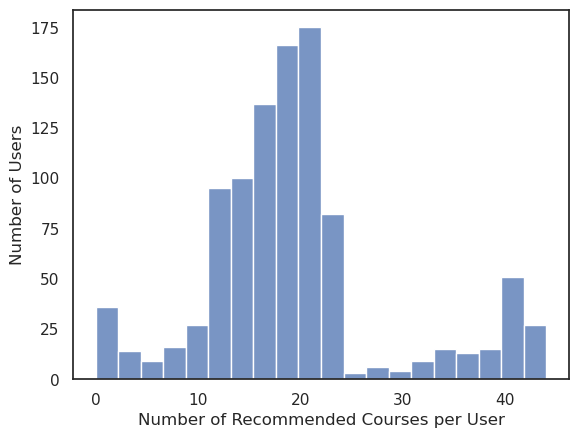

In [ ]:
sns.histplot(res_df["COUNTS"], bins=20)
plt.xlabel("Number of Recommended Courses per User")
plt.ylabel("Number of Users")

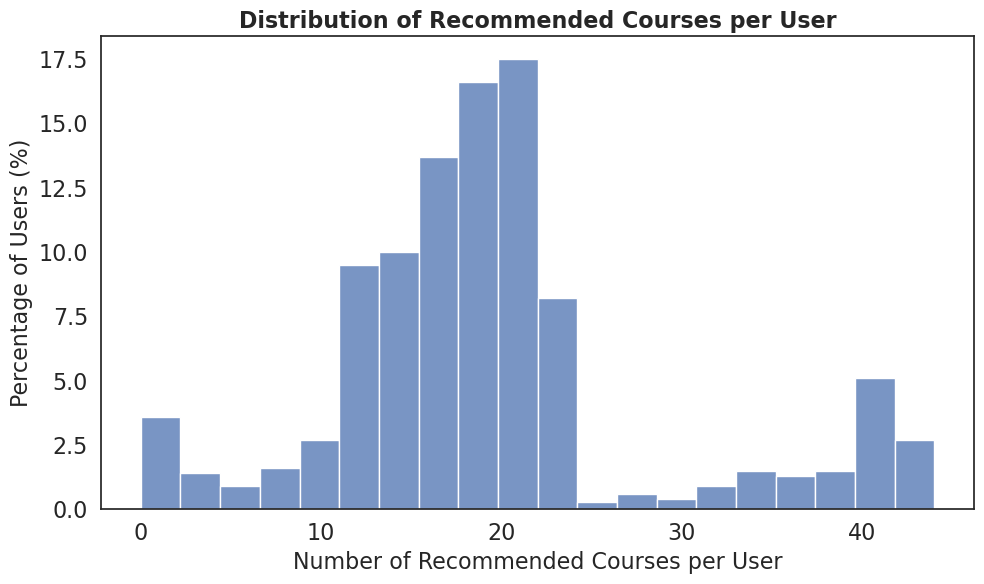

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(res_df["COUNTS"], bins=20, stat="percent")  # 👈 THIS is the key

plt.xlabel("Number of Recommended Courses per User", fontsize=16)
plt.ylabel("Percentage of Users (%)", fontsize=16)
plt.title(
    "Distribution of Recommended Courses per User",
    fontsize=16,
    fontweight="bold",
)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

#### **Determine the most frequently recommended courses across all test users**

In [ ]:
top_10_courses = (
    res_df.explode("COURSE_ID")["COURSE_ID"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)
top_10_courses = pd.DataFrame(top_10_courses)
top_10_courses

,count
COURSE_ID,
ST0101EN,728
CC0101EN,715
ML0115EN,702
BD0211EN,677
DB0101EN,676
DS0103EN,660
CL0101EN,621
DA0101EN,613
DS0105EN,597


Text(0, 0.5, 'Course ID')

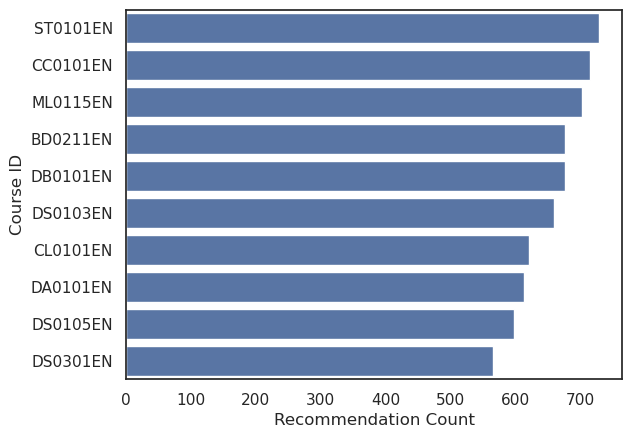

In [ ]:
sns.barplot(data=top_10_courses, x="count", y="COURSE_ID")
plt.xlabel("Recommendation Count")
plt.ylabel("Course ID")

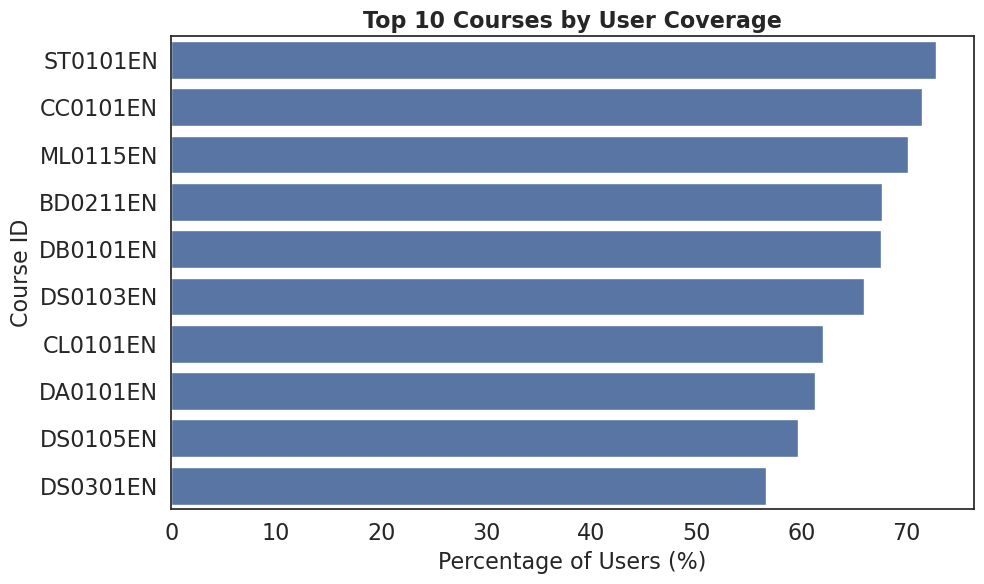

In [ ]:
# Convert list → multiple rows
res_df_exploded = res_df.explode("COURSE_ID")

course_user_counts = res_df_exploded.groupby("COURSE_ID")["USER"].nunique()
total_users = res_df_exploded["USER"].nunique()
course_user_percentage = (course_user_counts / total_users) * 100
top10_pct = course_user_percentage.sort_values(ascending=False).head(10)

top10_pct_df = top10_pct.reset_index()
top10_pct_df.columns = ["COURSE_ID", "USER_PERCENT"]

plt.figure(figsize=(10, 6))

sns.barplot(data=top10_pct_df, x="USER_PERCENT", y="COURSE_ID")

plt.xlabel("Percentage of Users (%)", fontsize=16)
plt.ylabel("Course ID", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Top 10 Courses by User Coverage", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### **Explore other clustering algorithms**


As you have learned in previous unsupervised learning course, there are many other clustering algorithms such as `DBSCAN` and `Hierarchical Clustering`. You are encouraged to try them on the user profile feature vectors and compare the results with K-means.


## **Summary**


In this lab, we have applied clustering algorithms to group users with similar interests and also tried PCA to reduce the dimensions of user feature vectors.

Furthermore, with each user finding its learning interest group, we have also implemented clustering-based course recommender system to make recommendations based on his/her group members' popular courses choices.


## **Authors**


[Yan Luo]((https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.
